In [1]:
import os
from glob import glob

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
from tqdm import tqdm
import cv2
from PIL import Image
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, 
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

import torch
from torch import optim, nn
import torch.nn.functional as F 
from torchvision import transforms as T, models
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler  

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# CUDA optimizations
torch.backends.cudnn.benchmark = True  # Auto-tune for faster convolutions
torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PATH = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB


### Load data

In [2]:
all_image_paths = {
    os.path.basename(p): p for p in glob(f'{PATH}/images_*/images/*.png')
}
print('Images found:', len(all_image_paths))

labels = pd.read_csv(f'{PATH}/Data_Entry_2017.csv')
labels.rename(columns={'Follow-up #' : 'follow_up', 'OriginalImage[Width': 'OriginalImageWidth', 'Height]': 'OriginalImageHeight', 'OriginalImagePixelSpacing[x': 'OriginalImagePixelSpacing_x', 'y]': 'OriginalImagePixelSpacing_y'}, inplace=True)
labels.columns = [
    re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col).capitalize().replace(' ', '_')
    for col in labels.columns
]
labels = labels[['Image_index', 'Finding_labels', 'Follow_up', 'Patient_id', 'Patient_age', 'Patient_gender', 'View_position']]

labels.loc[labels['Patient_age'] > 100, 'Patient_age'] = np.nan #Min: 148, Max: 414 yrs old
labels['Patient_age'] = labels.groupby('Patient_id')['Patient_age'].ffill().bfill()

label_cols = labels['Finding_labels'].str.get_dummies(sep='|')
labels = pd.concat([labels, label_cols], axis=1)
labels['Finding_labels'] = np.where(labels['Finding_labels'] == 'No Finding', 0, 1)
# labels.drop(columns=['Finding_labels'], inplace=True)
labels.rename(columns={'No Finding': 'No_Finding'}, inplace=True)
labels.sort_values(by=['Patient_id', 'Follow_up'], inplace=True)
labels.head()

Images found: 112120


,Image_index,Finding_labels,Follow_up,Patient_id,Patient_age,Patient_gender,View_position,Atelectasis,Cardiomegaly,Consolidation,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No_Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,1,0,1,58.0,M,PA,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,1,1,1,58.0,M,PA,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,1,2,1,58.0,M,PA,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,0,0,2,81.0,M,PA,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,1,0,3,81.0,F,PA,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [3]:
# Random split
# patient_ids = labels['Patient_id'].unique()
# np.random.shuffle(patient_ids)

# n_train = int(len(patient_ids) * 0.8)
# train_patients = patient_ids[: n_train]
# test_patients = patient_ids[n_train :]

# train_labels = labels[labels['Patient_id'].isin(train_patients)].reset_index(drop=True)
# test_labels = labels[labels['Patient_id'].isin(test_patients)].reset_index(drop=True)

with open(f'{PATH}/train_val_list.txt', 'r') as file:
    train_list = file.read().split('\n')

with open(f'{PATH}/test_list.txt', 'r') as file:
    test_list = file.read().split('\n')

train_labels = labels.loc[labels['Image_index'].isin(train_list)].copy()
test_labels = labels.loc[labels['Image_index'].isin(test_list)].copy()

print(f'Train shape: {train_labels.shape}')
print(f'Test shape: {test_labels.shape}')
assert set(train_labels['Patient_id']).isdisjoint(test_labels['Patient_id'])

Train shape: (86524, 22)
Test shape: (25596, 22)


In [4]:
# Basic dataset information
print('=== Basic Dataset Information ===')
print(f'Total number of images: {len(labels)}')
print(f'Total number of unique patients: {labels['Patient_id'].nunique()}')
print(f'Dataset shape: {labels.shape}')

print('\n=== Train Set Information ===')
print(f'Number of images (train): {len(train_labels)}')
print(f'Number of unique patients (train): {train_labels['Patient_id'].nunique()}')
print(f'Train set shape: {train_labels.shape}')

print('\n=== Test Set Information ===')
print(f'Number of images (test): {len(test_labels)}')
print(f'Number of unique patients (test): {test_labels['Patient_id'].nunique()}')
print(f'Test set shape: {test_labels.shape}')

=== Basic Dataset Information ===
Total number of images: 112120
Total number of unique patients: 30805
Dataset shape: (112120, 22)

=== Train Set Information ===
Number of images (train): 86524
Number of unique patients (train): 28008
Train set shape: (86524, 22)

=== Test Set Information ===
Number of images (test): 25596
Number of unique patients (test): 2797
Test set shape: (25596, 22)


In [5]:
disease_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Class distributions
disease_counts_train = train_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_train = train_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)
disease_counts_test = test_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_test = test_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)

# Percentage of disease labels on train data
disease_pct = (disease_counts_include_nf_train / len(train_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')

# Percentage of disease labels on test data
disease_pct = (disease_counts_include_nf_test / len(test_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')


Disease prevalence (%):
No_Finding            58.37
Infiltration          15.93
Effusion              10.01
Atelectasis            9.57
Nodule                 5.44
Mass                   4.66
Consolidation          3.30
Pneumothorax           3.05
Pleural_Thickening     2.59
Cardiomegaly           1.97
Emphysema              1.64
Edema                  1.59
Fibrosis               1.45
Pneumonia              1.01
Hernia                 0.16
dtype: float64

Disease prevalence (%):
No_Finding            38.53
Infiltration          23.88
Effusion              18.20
Atelectasis           12.81
Pneumothorax          10.41
Consolidation          7.09
Mass                   6.83
Nodule                 6.34
Pleural_Thickening     4.47
Emphysema              4.27
Cardiomegaly           4.18
Edema                  3.61
Pneumonia              2.17
Fibrosis               1.70
Hernia                 0.34
dtype: float64


In [6]:
# def create_balanced_subset(df, disease_cols, samples_per_class=100, min_total=2000):
#     selected_indices = set()
    
#     for col in disease_cols:
#         positive_indices = df[df[col] == 1].index.tolist()
#         n_select = min(samples_per_class, len(positive_indices))
#         selected_indices.update(np.random.choice(positive_indices, n_select, replace=False))
    
#     remaining_indices = list(set(df.index) - selected_indices)
#     n_remaining = max(0, min_total - len(selected_indices))
#     if n_remaining > 0 and len(remaining_indices) > 0:
#         additional = np.random.choice(remaining_indices, min(n_remaining, len(remaining_indices)), replace=False)
#         selected_indices.update(additional)
    
#     subset_df = df.loc[list(selected_indices)].reset_index(drop=True)
#     return subset_df

# # Train test subset
# train_labels_subset = create_balanced_subset(train_labels, disease_cols, samples_per_class=150, min_total=3000)
# test_labels_subset = create_balanced_subset(test_labels, disease_cols, samples_per_class=50, min_total=800)

# print('=== Train Subset ===')
# print(f'Total samples: {len(train_labels_subset)}')
# print('Samples per class:')
# print(train_labels_subset[disease_cols].sum().to_string())

# print('\n=== Test Subset ===')
# print(f'Total samples: {len(test_labels_subset)}')
# print('Samples per class:')
# print(test_labels_subset[disease_cols].sum().to_string())

# train_labels = train_labels_subset
# test_labels = test_labels_subset

### Preprocessing

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, data, image_paths, label_cols, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_paths = image_paths   
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_name = self.data.iloc[index]['Image_index']
        img_path = self.image_paths.get(img_name)

        if img_path is None:
            raise FileNotFoundError(f'Image not found: {img_name}')

        img = Image.open(img_path).convert('RGB')
        label = self.data.iloc[index][self.label_cols].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = T.Compose([
    T.Resize((256, 256)), 
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# train_transform = T.Compose([
#     T.Resize((256, 256)), 
#     T.RandomResizedCrop(224, scale=(0.8, 1.0)),  
#     T.RandomRotation(15),
#     T.ColorJitter(brightness=0.2, contrast=0.2), 
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     T.RandomErasing(p=0.1, scale=(0.02, 0.1))  
# ])

# test_transform = T.Compose([
#     T.Resize((256, 256)),
#     T.CenterCrop(224),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train = ImageDataset(train_labels, image_paths=all_image_paths, label_cols=disease_cols, transform=train_transform)
test = ImageDataset(test_labels, image_paths=all_image_paths, label_cols=disease_cols, transform=test_transform)
print(f'Length of trainset: {len(train)}')
print(f'Length of testset: {len(test)}')
print(f'Number of classes: {len(disease_cols)}')

Length of trainset: 86524
Length of testset: 25596
Number of classes: 14


Text(0.5, 1.0, 'Cardiomegaly')

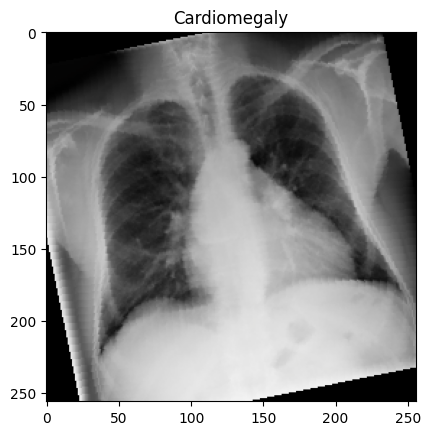

In [8]:
def deprocess(img):
    img = img.permute(1,2,0) #(C, H, W) -> (H, W, C) for ploting matplotlib
    img = img * torch.Tensor([0.229, 0.224, 0.225]) + torch.Tensor([0.485, 0.456, 0.406])
    return img

image, label = train[0]
class_labels = list(np.where(label==1)[0])
plt.imshow(deprocess(image))
plt.title(', '.join([disease_cols[i] for i in class_labels]))

In [9]:
# Optimize DataLoader for GPU
NUM_WORKERS = 4  
PIN_MEMORY = torch.cuda.is_available() 

train_loader = DataLoader(train, batch_size=64, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False)
test_loader = DataLoader(test, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=True if NUM_WORKERS > 0 else False)

### Model

In [10]:
class Net(nn.Module):
    def __init__(self, num_classes=14, dropout_rate=0.5):
        super(Net, self).__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        
        for name, param in self.backbone.named_parameters():
            if 'features.0' in name or 'features.1' in name or 'features.2' in name or \
               'features.3' in name or 'features.4' in name:
                param.requires_grad = False
        
        num_features = self.backbone.classifier[1].in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(inplace=True), 
            nn.Dropout(dropout_rate),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            
            nn.Linear(256, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.backbone.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.backbone(x)

model = Net(num_classes=len(disease_cols), dropout_rate=0.5).to(device)
print(f'Model: EfficientNet-B0')
print(f'Model loaded on: {device}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 229MB/s]


Model: EfficientNet-B0
Model loaded on: cuda
Total parameters: 4,799,882
Trainable parameters: 4,491,222


### Training

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, pos_weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets, 
            pos_weight=self.pos_weight,
            reduction='none'
        )
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        return focal_loss.mean()

def weighted_loss(pos_weights, neg_weights, y_pred, y_true, epsilon=1e-7):
    loss = 0.0
    for i in range(len(pos_weights)):
        loss_pos = -1 * torch.mean(pos_weights[i] * y_true[:,i] * torch.log(y_pred[:,i] + epsilon))
        loss_neg = -1 * torch.mean(neg_weights[i] * (1-y_true[:,i]) * torch.log((1-y_pred[:,i]) + epsilon))
        loss += loss_pos + loss_neg
    return loss

In [12]:
# ==================== TRAINING CONFIGURATION ====================
epochs = 30 
n_folds = 3  
batch_size = 64  
learning_rate = 5e-4 
weight_decay = 1e-4 

scaler = GradScaler('cuda') if torch.cuda.is_available() else None
use_amp = torch.cuda.is_available()

# Class weights
freq = train_labels[disease_cols].sum(axis=0).values
total = len(train_labels)
pos_weight = torch.tensor((total - freq) / (freq + 1e-6), dtype=torch.float32, device=device)
print('Class weights (pos_weight):')
for i, col in enumerate(disease_cols):
    print(f'  {col}: {pos_weight[i].item():.2f}')

groups = train_labels['Patient_id'].values
gkf = GroupKFold(n_splits=5)

train_losses = []
val_losses = []
val_aucs = []
best_models = []

print(f'\n=== Training Configuration ===')
print(f'Epochs: {epochs}')
print(f'Folds: {n_folds}')
print(f'Batch size: {batch_size}')
print(f'Learning rate: {learning_rate}')
print(f'Weight decay: {weight_decay}')
print(f'Loss: Focal Loss\n')

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_labels, groups=groups)):
    if fold >= n_folds:
        break
        
    print(f'\n{'='*25} Fold {fold + 1}/{n_folds} {'='*25}')
    
    train_subset = Subset(train, train_idx)
    val_subset = Subset(train, val_idx)
    loader_train = DataLoader(train_subset, batch_size=batch_size, shuffle=True, 
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, 
                              persistent_workers=True if NUM_WORKERS > 0 else False)
    loader_val = DataLoader(val_subset, batch_size=batch_size, shuffle=False, 
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                            persistent_workers=True if NUM_WORKERS > 0 else False)
    
    print(f'Train size: {len(train_subset)}, Val size: {len(val_subset)}')
    
    model = Net(num_classes=len(disease_cols), dropout_rate=0.5).to(device)
    criterion = FocalLoss(alpha=1, gamma=2, pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-6  
    )
    valid_loss_min = np.inf
    best_val_auc = 0.0
    fold_train_losses = []
    fold_val_losses = []
    fold_val_aucs = []
    patience_counter = 0
    early_stop_patience = 5  
    
    for epoch in range(epochs):
        current_lr = optimizer.param_groups[0]['lr']
        
        # ========== Training ==========
        model.train()
        train_loss = 0.0
        
        train_pbar = tqdm(loader_train, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Train]')
        for images, labels_batch in train_pbar:
            images = images.to(device, non_blocking=True)
            labels_batch = labels_batch.float().to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels_batch)
                
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})
        
        scheduler.step()
        
        avg_train_loss = train_loss / len(loader_train)
        fold_train_losses.append(avg_train_loss)
        
        # ========== Validation ==========
        model.eval()
        valid_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            val_pbar = tqdm(loader_val, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Val]')
            for images, labels_batch in val_pbar:
                images = images.to(device, non_blocking=True)
                labels_batch = labels_batch.float().to(device, non_blocking=True)
                
                if use_amp:
                    with autocast('cuda'):
                        outputs = model(images)
                        loss = criterion(outputs, labels_batch)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels_batch)
                
                valid_loss += loss.item()
                
                preds = torch.sigmoid(outputs)
                all_preds.append(preds.cpu())
                all_labels.append(labels_batch.cpu())
                
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_valid_loss = valid_loss / len(loader_val)
        fold_val_losses.append(avg_valid_loss)
        
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        val_acc = ((all_preds >= 0.5) == all_labels).mean() * 100
        
        # Calculate mean AUC-ROC
        try:
            val_auc = roc_auc_score(all_labels, all_preds, average='macro') * 100
        except:
            val_auc = 0.0
        fold_val_aucs.append(val_auc)
        
        # Save best model based on AUC
        if val_auc > best_val_auc:
            print(f'=> Val AUC improved ({best_val_auc:.2f}% -> {val_auc:.2f}%). Saving model...')
            torch.save({
                'fold': fold,
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'valid_loss': avg_valid_loss,
                'val_auc': val_auc,
                'val_accuracy': val_acc
            }, f'model_fold{fold+1}.pt')
            best_val_auc = val_auc
            valid_loss_min = avg_valid_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f} | Val Loss = {avg_valid_loss:.6f} | Val Acc = {val_acc:.2f}% | Val AUC = {val_auc:.2f}% | LR = {current_lr:.2e}')
        
        if patience_counter >= early_stop_patience:
            print(f'Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)')
            break
    
    train_losses.append(fold_train_losses)
    val_losses.append(fold_val_losses)
    val_aucs.append(fold_val_aucs)
    best_models.append(f'model_fold{fold+1}.pt')

print('\nTraining completed!')
print(f'Best models saved: {best_models}')
print(f'Best validation AUC: {best_val_auc:.2f}%')

Class weights (pos_weight):
  Atelectasis: 9.45
  Cardiomegaly: 49.69
  Consolidation: 29.34
  Edema: 61.79
  Effusion: 8.99
  Emphysema: 59.80
  Fibrosis: 68.16
  Hernia: 612.65
  Infiltration: 5.28
  Mass: 20.45
  Nodule: 17.38
  Pleural_Thickening: 37.59
  Pneumonia: 97.77
  Pneumothorax: 31.81

=== Training Configuration ===
Epochs: 30
Folds: 3
Batch size: 64
Learning rate: 0.0005
Weight decay: 0.0001
Loss: Focal Loss


========================= Fold 1/3 =========================
Train size: 69219, Val size: 17305


Fold 1 | Epoch 1/30 [Train]: 100%|██████████| 1082/1082 [11:37<00:00,  1.55it/s, loss=0.6580, lr=5.00e-04]
Fold 1 | Epoch 1/30 [Val]: 100%|██████████| 271/271 [02:46<00:00,  1.63it/s, loss=0.9929]


=> Val AUC improved (0.00% -> 74.72%). Saving model...
Epoch 1: Train Loss = 1.224596 | Val Loss = 0.810631 | Val Acc = 42.98% | Val AUC = 74.72% | LR = 5.00e-04


Fold 1 | Epoch 2/30 [Train]: 100%|██████████| 1082/1082 [10:40<00:00,  1.69it/s, loss=0.5423, lr=4.52e-04]
Fold 1 | Epoch 2/30 [Val]: 100%|██████████| 271/271 [02:42<00:00,  1.67it/s, loss=0.9419]


=> Val AUC improved (74.72% -> 78.61%). Saving model...
Epoch 2: Train Loss = 0.870749 | Val Loss = 0.667110 | Val Acc = 57.27% | Val AUC = 78.61% | LR = 4.52e-04


...

Epoch 8: Train Loss = 0.700925 | Val Loss = 0.656804 | Val Acc = 64.53% | Val AUC = 80.92% | LR = 4.52e-04


Fold 3 | Epoch 9/30 [Train]: 100%|██████████| 1082/1082 [10:48<00:00,  1.67it/s, loss=0.6899, lr=3.97e-04]
Fold 3 | Epoch 9/30 [Val]: 100%|██████████| 271/271 [02:43<00:00,  1.66it/s, loss=0.8802]


Epoch 9: Train Loss = 0.659378 | Val Loss = 0.676376 | Val Acc = 67.27% | Val AUC = 81.19% | LR = 3.97e-04


Fold 3 | Epoch 10/30 [Train]: 100%|██████████| 1082/1082 [10:50<00:00,  1.66it/s, loss=0.3315, lr=3.28e-04]
Fold 3 | Epoch 10/30 [Val]: 100%|██████████| 271/271 [02:41<00:00,  1.68it/s, loss=0.7927]

Epoch 10: Train Loss = 0.618714 | Val Loss = 1.042152 | Val Acc = 70.57% | Val AUC = 81.07% | LR = 3.28e-04
Early stopping at epoch 10 (no improvement for 5 epochs)

Training completed!
Best models saved: ['model_fold1.pt', 'model_fold2.pt', 'model_fold3.pt']
Best validation AUC: 81.60%


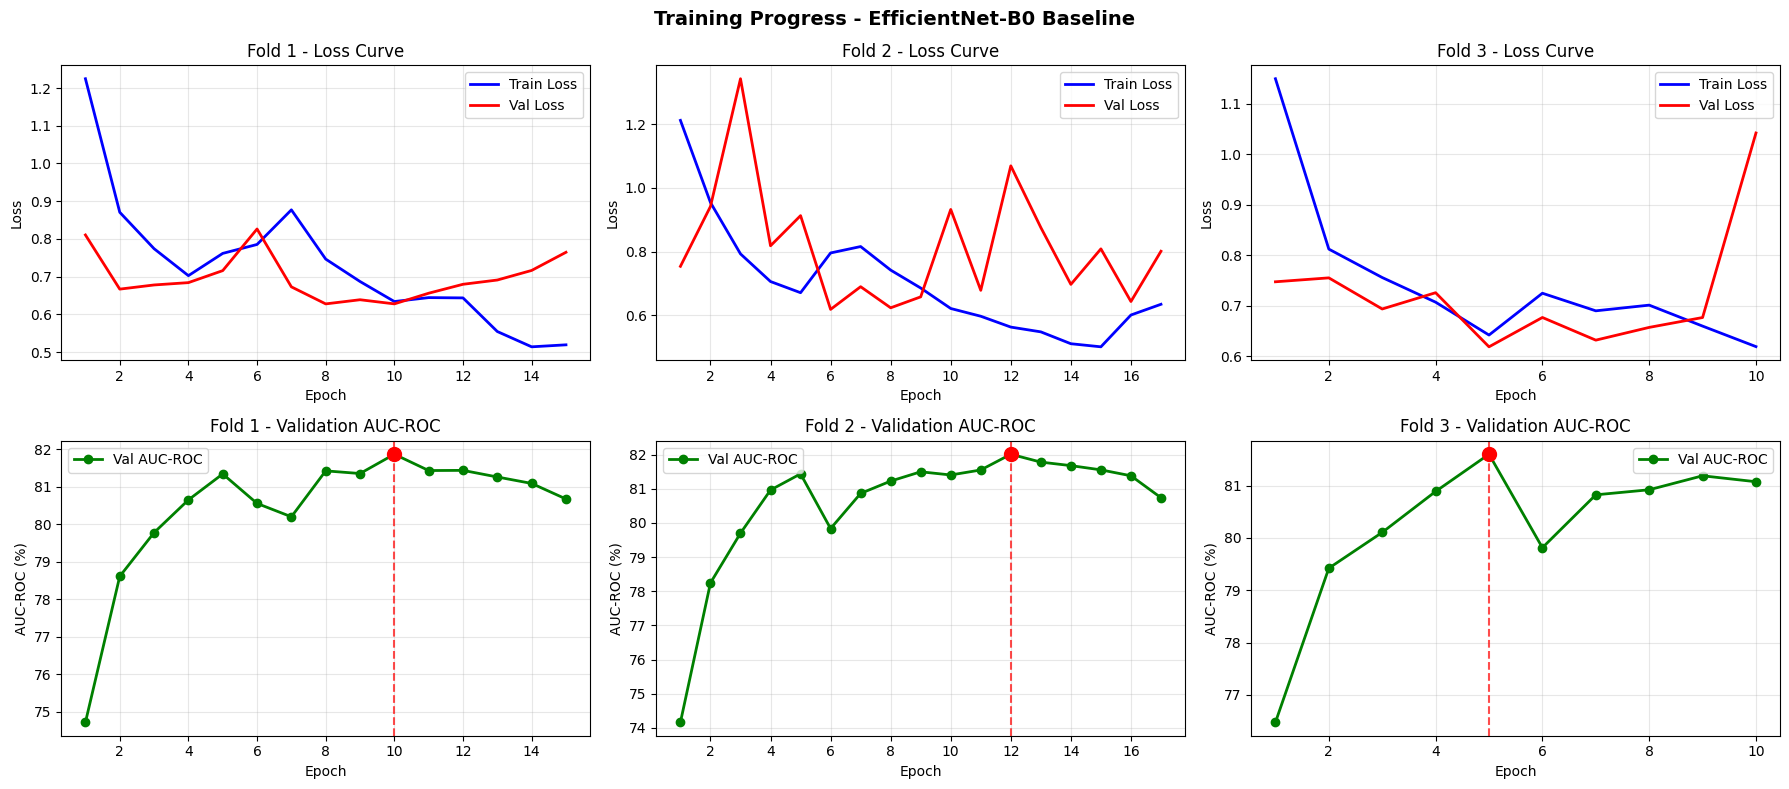

Best validation AUC across folds: 82.01%


In [13]:
fig, axes = plt.subplots(2, len(train_losses), figsize=(6*len(train_losses), 8))
if len(train_losses) == 1:
    axes = axes.reshape(2, 1)

for i, (train_loss, val_loss, val_auc) in enumerate(zip(train_losses, val_losses, val_aucs)):
    # Loss curve
    axes[0, i].plot(range(1, len(train_loss)+1), train_loss, 'b-', label='Train Loss', linewidth=2)
    axes[0, i].plot(range(1, len(val_loss)+1), val_loss, 'r-', label='Val Loss', linewidth=2)
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'Fold {i+1} - Loss Curve')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)
    
    # AUC curve
    axes[1, i].plot(range(1, len(val_auc)+1), val_auc, 'g-', label='Val AUC-ROC', linewidth=2, marker='o')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('AUC-ROC (%)')
    axes[1, i].set_title(f'Fold {i+1} - Validation AUC-ROC')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)
    
    # Mark best epoch
    best_epoch = np.argmax(val_auc) + 1
    best_auc = max(val_auc)
    axes[1, i].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_auc:.2f}%')
    axes[1, i].scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)

plt.suptitle('Training Progress - EfficientNet-B0 Baseline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best validation AUC across folds: {max([max(auc) for auc in val_aucs]):.2f}%')

In [14]:
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, 
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

def evaluate_model(dataloader, model, disease_cols, threshold=0.5, dataset_name='Dataset'):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'Evaluating {dataset_name}'):
            images = images.to(device, non_blocking=True)
            
            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
            else:
                outputs = model(images)
            
            preds = torch.sigmoid(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
    
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    # Per-class comprehensive metrics
    results = []
    for i, col in enumerate(disease_cols):
        pred_binary = (all_preds[:, i] >= threshold).astype(int)
        true_labels = all_labels[:, i].astype(int)
        
        tp = ((pred_binary == 1) & (true_labels == 1)).sum()
        tn = ((pred_binary == 0) & (true_labels == 0)).sum()
        fp = ((pred_binary == 1) & (true_labels == 0)).sum()
        fn = ((pred_binary == 0) & (true_labels == 1)).sum()
        
        accuracy = (pred_binary == true_labels).mean() * 100
        
        try:
            auc = roc_auc_score(true_labels, all_preds[:, i]) * 100
        except:
            auc = 0.0
        
        precision = precision_score(true_labels, pred_binary, zero_division=0) * 100
        recall = recall_score(true_labels, pred_binary, zero_division=0) * 100
        f1 = f1_score(true_labels, pred_binary, zero_division=0) * 100
        
        results.append({
            'Disease': col,
            'Accuracy': round(accuracy, 2),
            'AUC-ROC': round(auc, 2),
            'Precision': round(precision, 2),
            'Recall': round(recall, 2),
            'F1-Score': round(f1, 2),
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Total_Positive': int(true_labels.sum()),
            'Predicted_Positive': int(pred_binary.sum())
        })
    
    df_results = pd.DataFrame(results)
    
    # Overall metrics
    print(f'\n{'='*60}')
    print(f'{dataset_name.upper()} EVALUATION RESULTS')
    print(f'{'='*60}')
    print(f'Overall Label Accuracy: {((all_preds >= threshold) == all_labels).mean() * 100:.2f}%')
    print(f'Mean AUC-ROC: {df_results['AUC-ROC'].mean():.2f}%')
    print(f'Mean F1-Score: {df_results['F1-Score'].mean():.2f}%')
    print(f'Mean Precision: {df_results['Precision'].mean():.2f}%')
    print(f'Mean Recall: {df_results['Recall'].mean():.2f}%')
    print(f'{'='*60}\n')
    
    return df_results, all_preds, all_labels


def plot_roc_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(disease_cols):
        ax = axes[i]
        
        try:
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            ax.plot(fpr, tpr, 'b-', label=f'AUC = {auc:.3f}')
            ax.plot([0, 1], [0, 1], 'r--', label='Random')
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')
    
    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'ROC Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_precision_recall_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()
    
    for i, col in enumerate(disease_cols):
        ax = axes[i]
        
        try:
            precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
            ap = average_precision_score(all_labels[:, i], all_preds[:, i])
            ax.plot(recall, precision, 'b-', label=f'AP = {ap:.3f}')
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower left')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')
    
    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'Precision-Recall Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def class_accuracy(dataloader, model):
    per_class_accuracy = [0 for i in range(len(disease_cols))]

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if use_amp:
                with autocast('cuda'):
                    ps = model(images)
            else:
                ps = model(images)
            
            ps = (torch.sigmoid(ps) >= 0.5).float() 

            for i in range(ps.shape[1]):
                x1 = ps[:,i:i+1]
                x2 = labels[:,i:i+1]
                per_class_accuracy[i] += int((x1 == x2).sum())

        per_class_accuracy = [(i/len(dataloader.dataset))*100.0 for i in per_class_accuracy]

    return per_class_accuracy     

def get_acc_data(class_names, acc_list):
    df = pd.DataFrame(list(zip(class_names, acc_list)), columns=['Labels', 'Acc']) 
    return df

TRAIN DATASET EVALUATION
Loaded model from fold 1, epoch 10
Best validation loss: 0.627994
Best validation AUC: 81.87%


Evaluating Train: 100%|██████████| 1352/1352 [13:35<00:00,  1.66it/s]



TRAIN EVALUATION RESULTS
Overall Label Accuracy: 69.38%
Mean AUC-ROC: 86.04%
Mean F1-Score: 18.15%
Mean Precision: 10.55%
Mean Recall: 87.44%


--- Detailed Train Results by Disease ---


,Disease,Accuracy,AUC-ROC,Precision,Recall,F1-Score,TP,TN,FP,FN,Total_Positive,Predicted_Positive
0,Atelectasis,60.72,82.00,18.07,87.81,29.97,7271,45268,32976,1009,8280,40247
1,Cardiomegaly,79.14,94.37,8.25,94.55,15.17,1614,66862,17955,93,1707,19569
2,Consolidation,65.92,82.70,7.63,84.08,13.99,2398,54641,29031,454,2852,31429
3,Edema,80.96,94.03,7.28,93.40,13.51,1287,68763,16383,91,1378,17670
4,Effusion,77.48,89.43,29.09,86.97,43.60,7531,59510,18355,1128,8659,25886
5,Emphysema,82.77,93.88,7.97,89.88,14.65,1279,70338,14763,144,1423,16042
6,Fibrosis,61.64,85.85,3.28,89.77,6.34,1123,52208,33065,128,1251,34188
7,Hernia,98.30,98.18,7.86,87.94,14.43,124,84929,1454,17,141,1578
8,Infiltration,31.50,69.23,18.17,94.16,30.46,12977,14282,58460,805,13782,71437
9,Mass,73.72,85.63,13.04,81.83,22.50,3301,60485,22005,733,4034,25306



--- ROC Curves (Train Set) ---


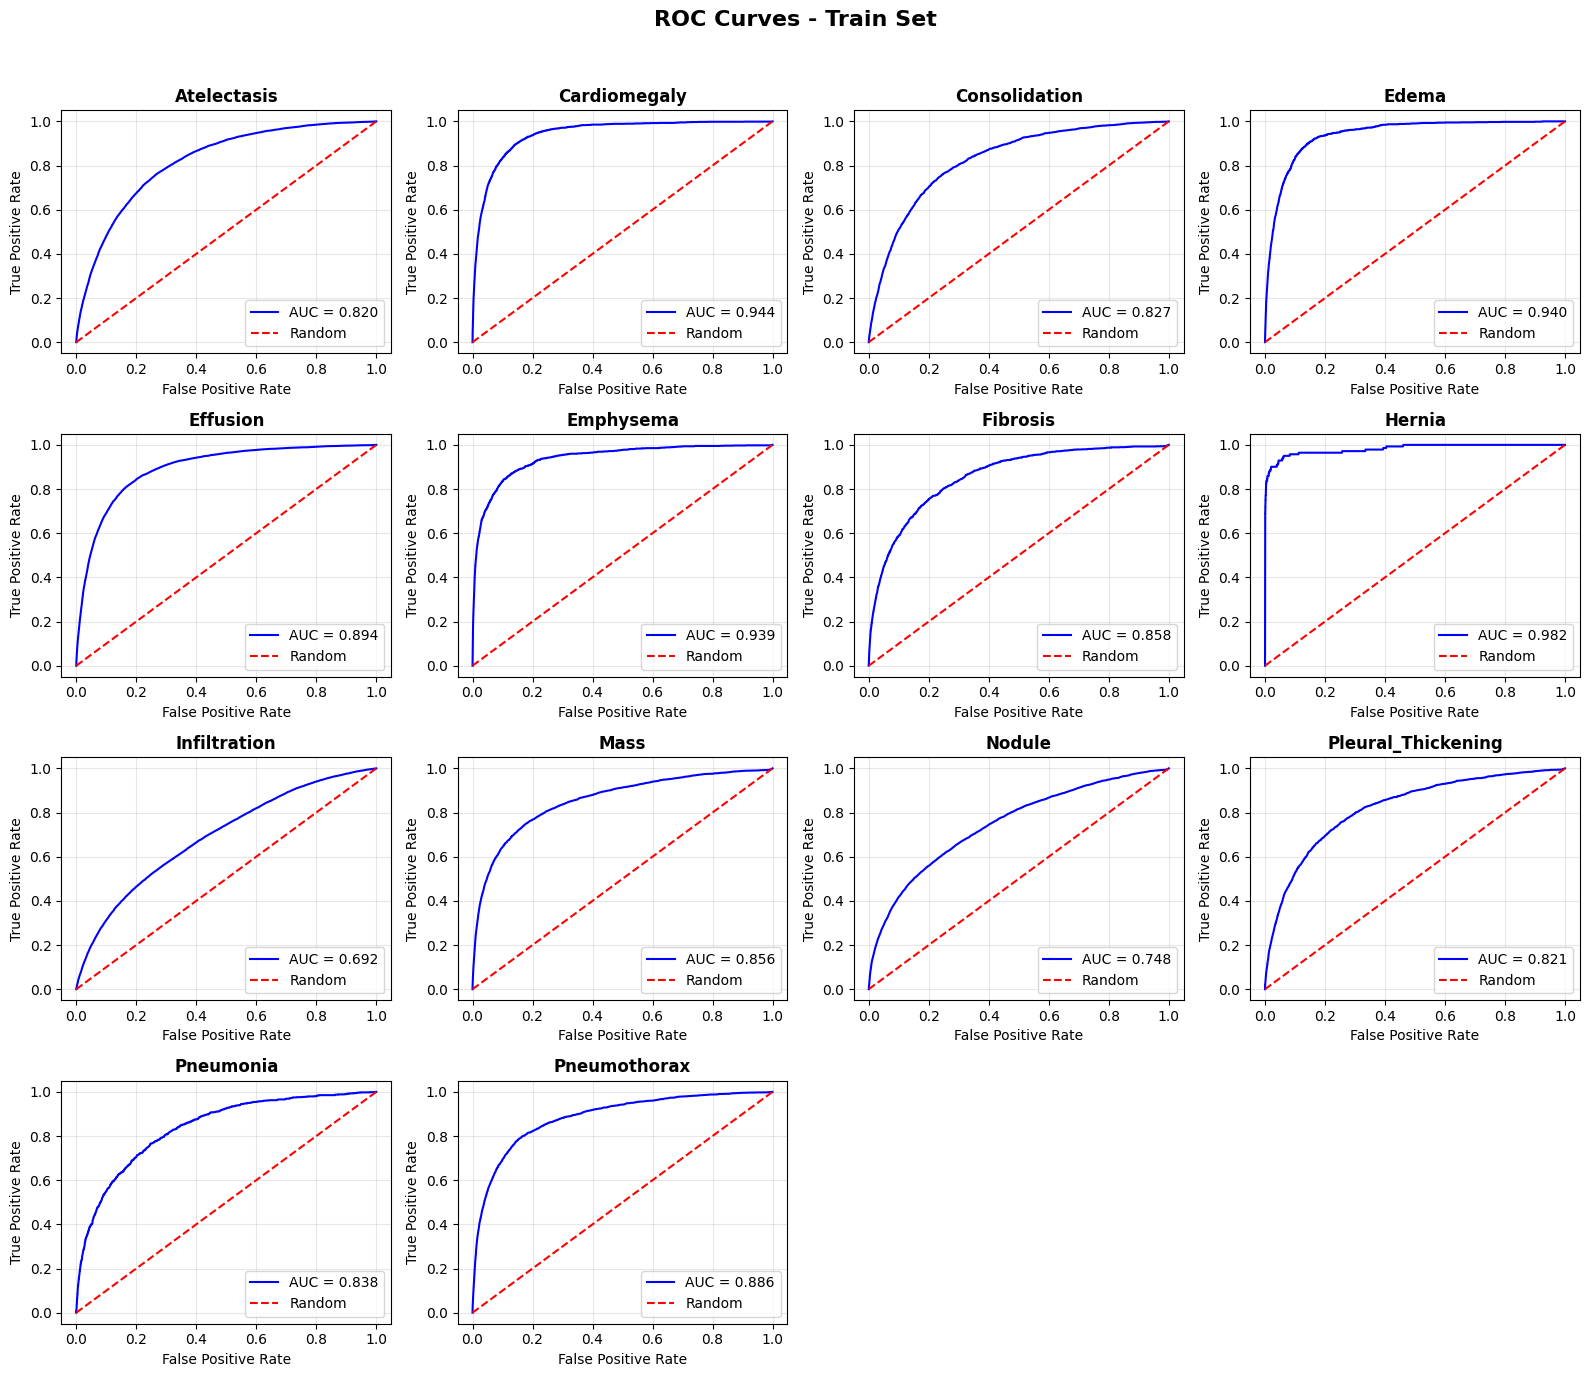


--- Precision-Recall Curves (Train Set) ---


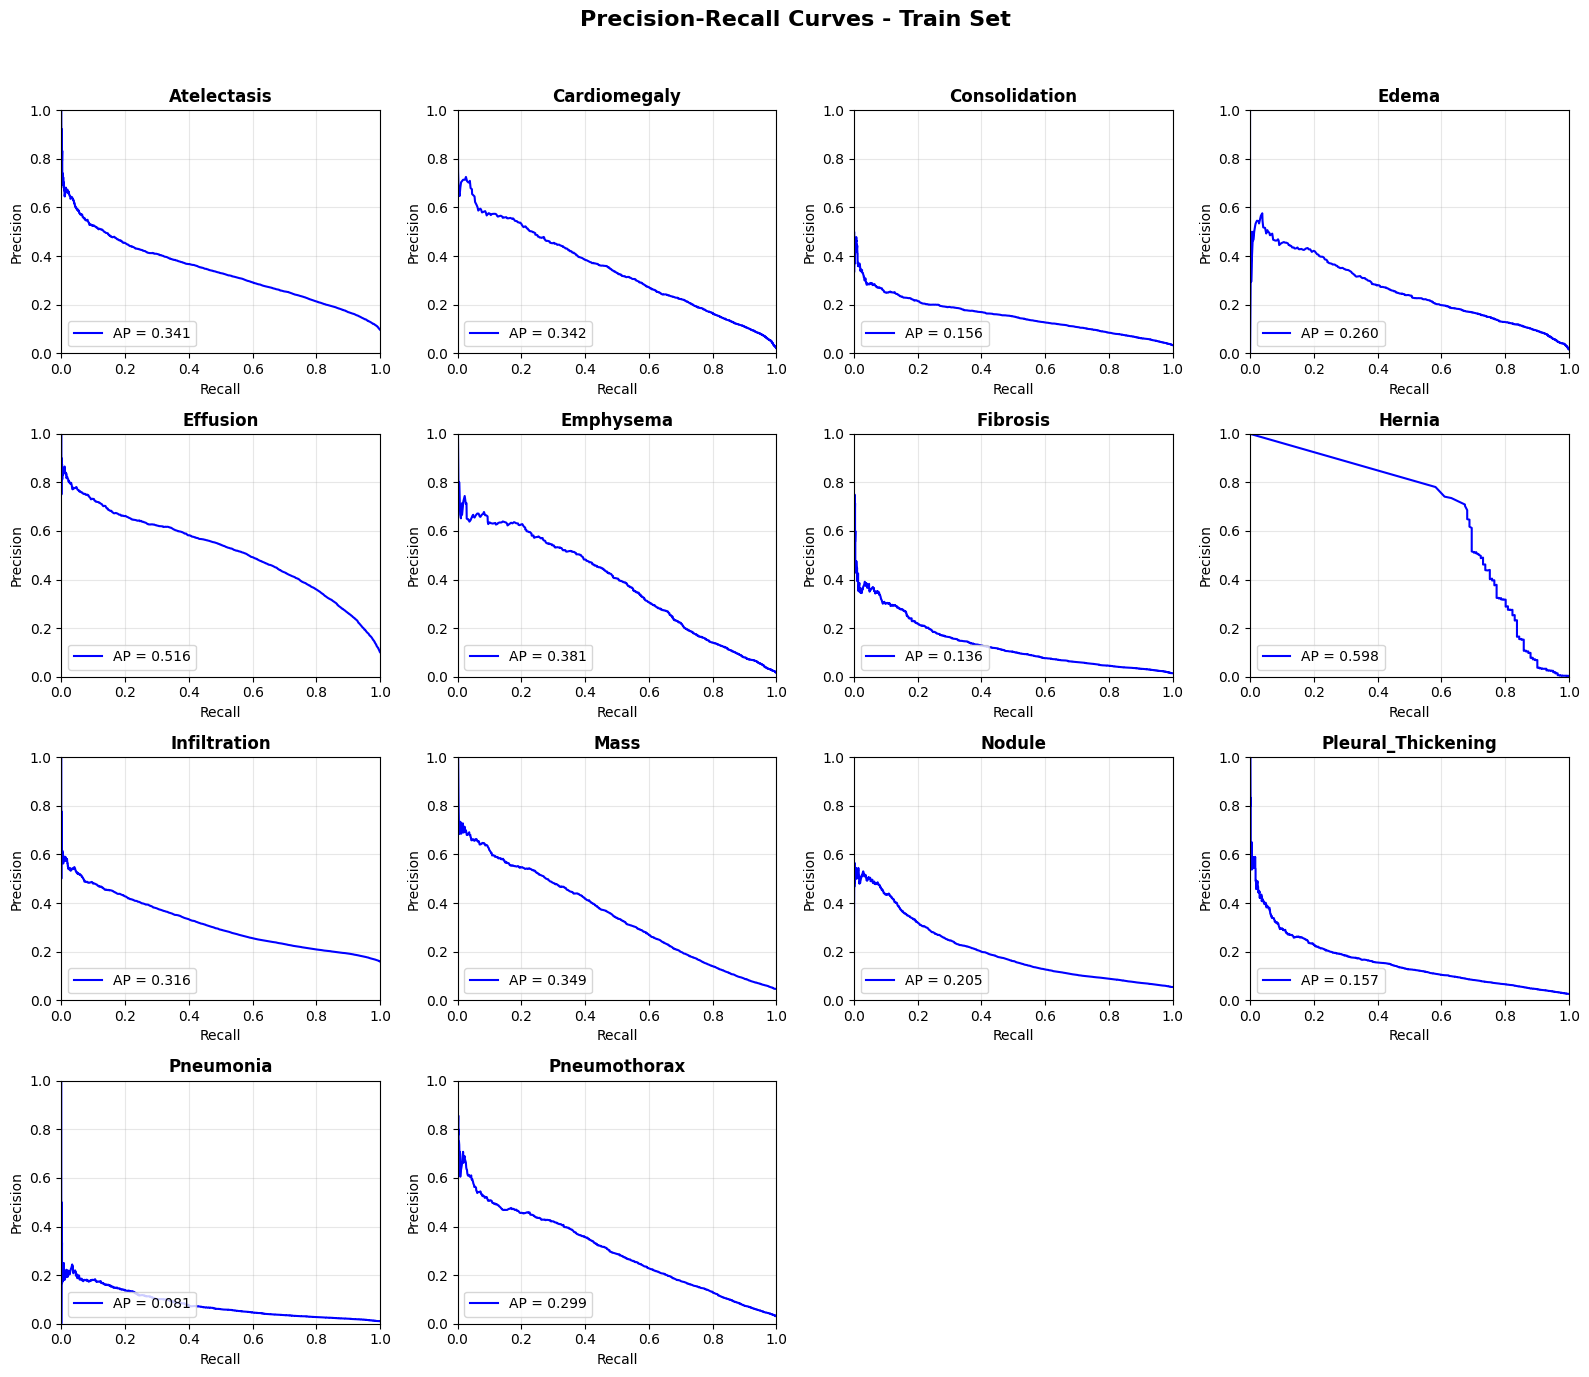

In [15]:
# TRAIN DATASET EVALUATION  
print('='*60)
print('TRAIN DATASET EVALUATION')
print('='*60)

checkpoint = torch.load('model_fold1.pt', weights_only=False, map_location=device)
model = Net(num_classes=len(disease_cols)).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Loaded model from fold 1, epoch {checkpoint['epoch']+1}')
print(f'Best validation loss: {checkpoint['valid_loss']:.6f}')
print(f'Best validation AUC: {checkpoint['val_auc']:.2f}%')

train_results, train_preds, train_true = evaluate_model(
    train_loader, model, disease_cols, threshold=0.5, dataset_name='Train'
)

print('\n--- Detailed Train Results by Disease ---')
display(train_results)

print('\n--- ROC Curves (Train Set) ---')
plot_roc_curves(train_true, train_preds, disease_cols, title_suffix=' - Train Set')

print('\n--- Precision-Recall Curves (Train Set) ---')
plot_precision_recall_curves(train_true, train_preds, disease_cols, title_suffix=' - Train Set')

TEST DATASET COMPREHENSIVE EVALUATION


Evaluating Test: 100%|██████████| 400/400 [04:13<00:00,  1.58it/s]



TEST EVALUATION RESULTS
Overall Label Accuracy: 57.38%
Mean AUC-ROC: 79.90%
Mean F1-Score: 22.36%
Mean Precision: 13.33%
Mean Recall: 86.57%


--- Detailed Test Results by Disease ---


,Disease,Accuracy,AUC-ROC,Precision,Recall,F1-Score,TP,TN,FP,FN,Total_Positive,Predicted_Positive
0,Atelectasis,48.08,76.06,18.47,89.39,30.61,2931,9376,12941,348,3279,15872
1,Cardiomegaly,67.57,87.58,10.42,89.06,18.66,952,16342,8185,117,1069,9137
2,Consolidation,37.84,74.57,9.75,94.10,17.68,1708,7978,15803,107,1815,17511
3,Edema,59.00,84.05,7.60,92.76,14.05,858,14244,10427,67,925,11285
4,Effusion,54.51,81.09,27.71,93.22,42.72,4342,9611,11327,316,4658,15669
5,Emphysema,74.67,90.27,13.20,88.47,22.98,967,18146,6357,126,1093,7324
6,Fibrosis,69.04,82.18,4.20,78.85,7.97,343,17329,7832,92,435,8175
7,Hernia,98.76,91.10,16.33,65.12,26.11,56,25223,287,30,86,343
8,Infiltration,30.68,70.04,25.27,97.25,40.12,5944,1909,17575,168,6112,23519
9,Mass,56.66,78.76,11.93,83.75,20.88,1464,13039,10809,284,1748,12273



--- ROC Curves (Test Set) ---


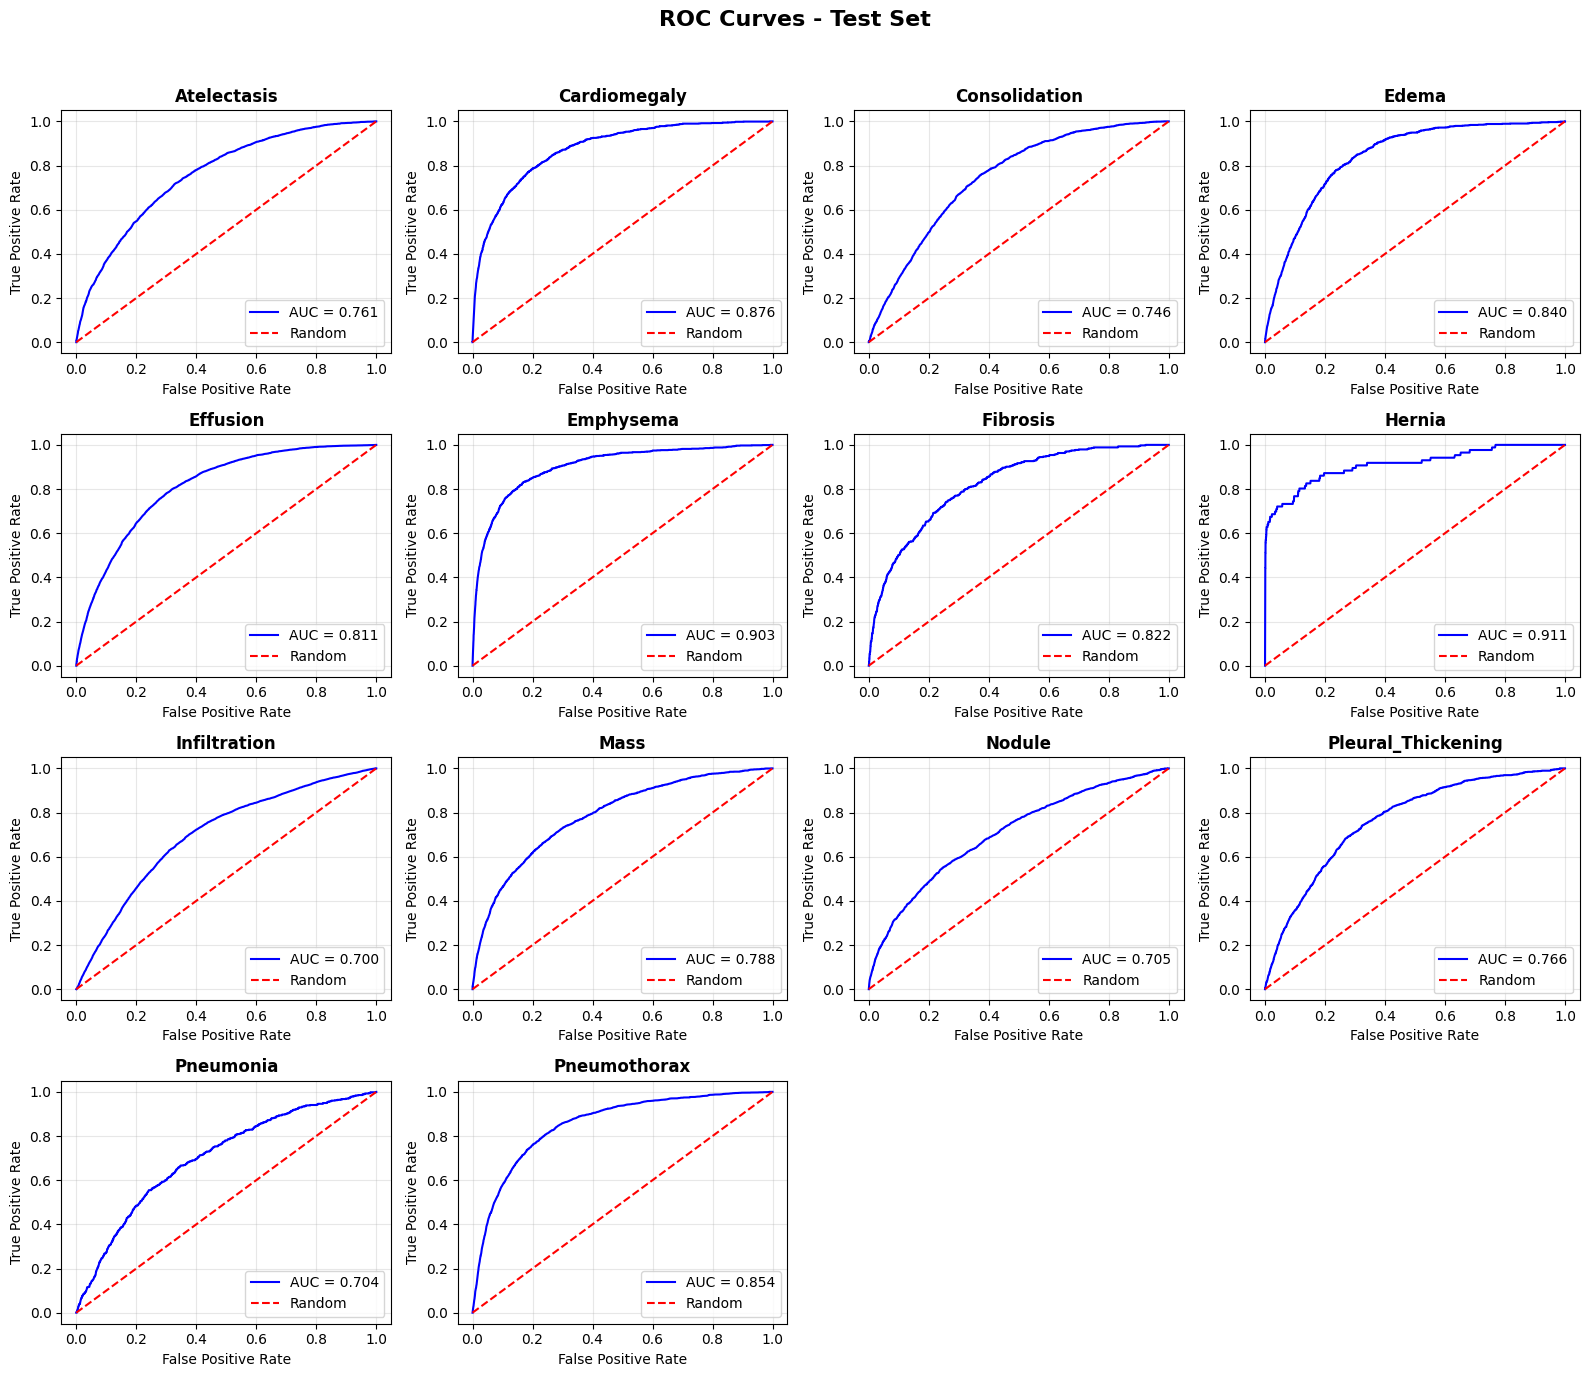


--- Precision-Recall Curves (Test Set) ---


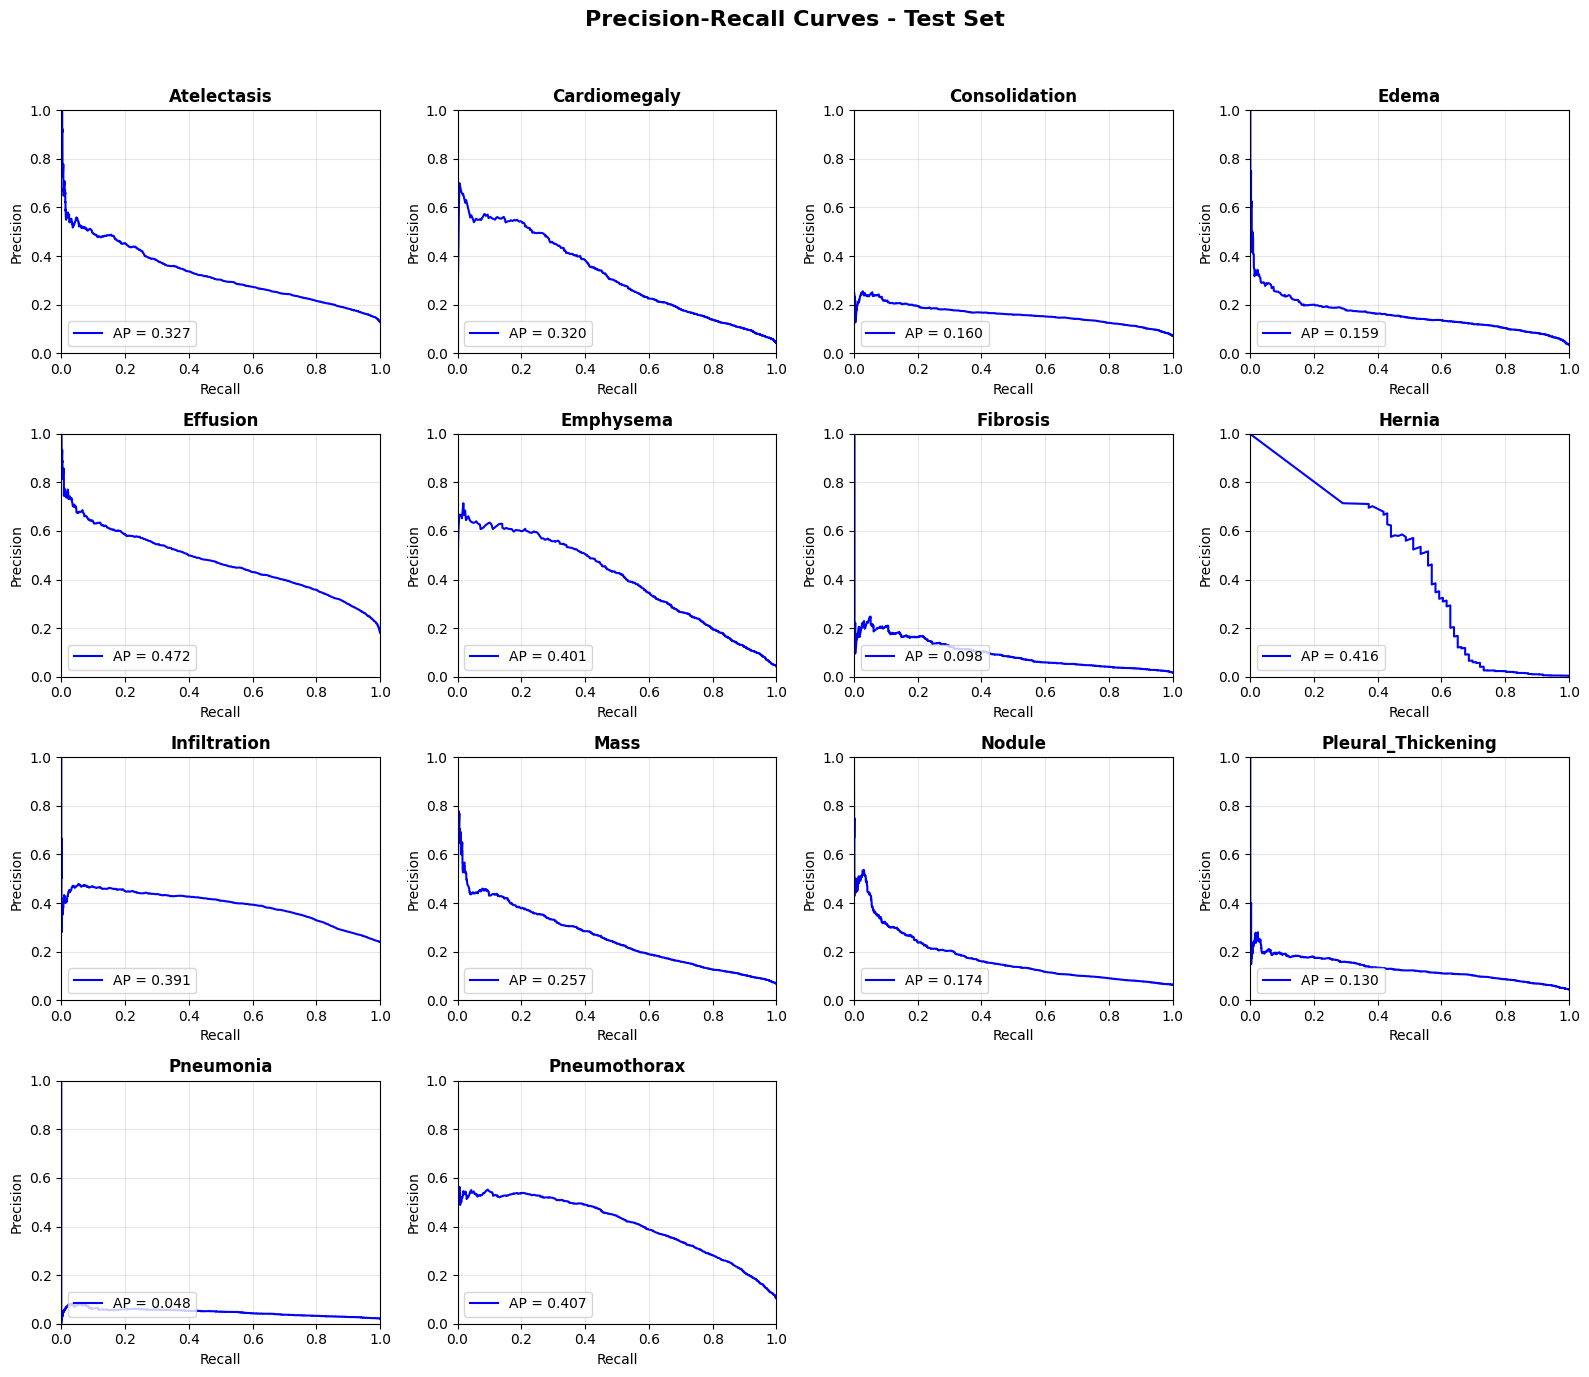


--- Class Accuracy (Test Set) ---


,Labels,Acc
0,Atelectasis,48.081732
1,Cardiomegaly,67.565245
2,Consolidation,37.841850
3,Edema,59.001406
4,Effusion,54.512424
5,Emphysema,74.671824
6,Fibrosis,69.042038
7,Hernia,98.761525
8,Infiltration,30.680575
9,Mass,56.661197



SUMMARY
Mean AUC-ROC (Test): 79.90%
Mean F1-Score (Test): 22.36%
Mean Precision (Test): 13.33%
Mean Recall (Test): 86.57%


In [16]:
# TEST DATASET COMPREHENSIVE EVALUATION
print('='*60)
print('TEST DATASET COMPREHENSIVE EVALUATION')
print('='*60)

test_results, test_preds, test_true = evaluate_model(
    test_loader, model, disease_cols, threshold=0.5, dataset_name='Test'
)

print('\n--- Detailed Test Results by Disease ---')
display(test_results)

print('\n--- ROC Curves (Test Set) ---')
plot_roc_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set')

print('\n--- Precision-Recall Curves (Test Set) ---')
plot_precision_recall_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set')

print('\n--- Class Accuracy (Test Set) ---')
acc_list = class_accuracy(test_loader, model)
acc_df = get_acc_data(disease_cols, acc_list)
display(acc_df)

# Summary comparison
print('\n' + '='*60)
print('SUMMARY')
print('='*60)
print(f'Mean AUC-ROC (Test): {test_results['AUC-ROC'].mean():.2f}%')
print(f'Mean F1-Score (Test): {test_results['F1-Score'].mean():.2f}%')
print(f'Mean Precision (Test): {test_results['Precision'].mean():.2f}%')
print(f'Mean Recall (Test): {test_results['Recall'].mean():.2f}%')
print('='*60)